# 🎵 Music CRS — Data Exploration

## What is this challenge?

Imagine a chatbot that helps you find music. You tell it what you're in the mood for, it asks follow-up questions, and eventually recommends a song. That's a **Conversational Recommender System (CRS)**.

This challenge gives us a dataset of exactly those conversations, and asks us to build a system that:

1. **Reads** a back-and-forth conversation about music preferences  
2. **Finds** the 20 most relevant tracks from a catalog of 47,071 songs  
3. **Writes** a friendly natural-language response explaining the recommendation  

### Why is it hard?

- The catalog has 47,071 tracks — like finding a needle in a haystack
- Preferences are vague: "something chill" or "like what I heard last summer"
- The system must track the whole conversation, not just the last message

### The pipeline (simplified)

```
Conversation History
       │
       ▼
  [BM25 Search]  ──── finds top-20 matching tracks from 47,071
       │
       ▼
  [Language Model]  ── writes a friendly recommendation response
       │
       ▼
  Predicted track IDs + response text
```

This notebook explores the three datasets that power the system.

In [1]:
import sys
sys.path.insert(0, "..")

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from IPython.display import display, HTML
from datasets import load_dataset

pd.set_option("display.max_colwidth", 80)
plt.rcParams["figure.dpi"] = 110
print("Ready!")

Ready!


---
## Dataset 1: Conversations

Each **session** is one full conversation between a user and a music assistant. The assistant eventually recommends a song — and the dataset records *which* song was recommended (that's our **ground truth** to predict).

| Split | Size | Description |
|-------|------|-------------|
| `train` | 15,199 sessions | Use this to study patterns |
| `test` | ~500 sessions | Dev set — we predict on this |
| `blind_a` | hidden | Submitted for scoring |

Each session has up to **8 rounds**. Each round has three turns:
- 🔵 `user` — what the listener says
- 🟢 `assistant` — what the recommender replies
- 🟡 `music` — the track recommended (**what we must predict**)

In [2]:
print("Loading conversations (train split)...")
conv_train = load_dataset("talkpl-ai/TalkPlayData-Challenge-Dataset", split="train")
print(f"Training sessions: {len(conv_train):,}")
print(f"\nFields in each session:")
for field, dtype in conv_train.features.items():
    print(f"  {field}: {dtype}")

Loading conversations (train split)...


Training sessions: 15,199

Fields in each session:
  session_id: Value('string')
  user_id: Value('string')
  session_date: Value('string')
  user_profile: {'age': Value('int64'), 'age_group': Value('string'), 'country_code': Value('string'), 'country_name': Value('string'), 'gender': Value('string'), 'preferred_language': Value('string'), 'preferred_musical_culture': Value('string'), 'user_id': Value('string'), 'user_split': Value('string')}
  conversation_goal: {'category': Value('string'), 'listener_goal': Value('string'), 'specificity': Value('string')}
  conversations: List({'content': Value('string'), 'role': Value('string'), 'thought': Value('string'), 'turn_number': Value('int64')})
  goal_progress_assessments: List({'goal_progress_assessment': Value('string'), 'turn_number': Value('int64')})


In [3]:
def display_conversation(session, track_meta=None):
    """Render a session as a color-coded HTML chat. Works in light and dark mode."""
    profile = session.get("user_profile", {})
    goal = session.get("conversation_goal", {})

    header = f"""
    <div style="border:1px solid rgba(99,102,241,0.4);border-left:4px solid #6366f1;
                padding:10px;border-radius:8px;margin-bottom:10px;font-size:0.9em">
      <b>Session:</b> {session['session_id'][:8]}...&nbsp;&nbsp;
      <b>User:</b> {profile.get('age_group','?')} {profile.get('gender','?')} from {profile.get('country_name','?')}<br>
      <b>Culture:</b> {profile.get('preferred_musical_culture','?')}<br>
      <b>Goal:</b> <i>{goal.get('listener_goal','?')[:140]}...</i>
    </div>
    """

    rows = []
    for turn in session["conversations"]:
        role = turn["role"]
        content = turn["content"]
        turn_num = turn["turn_number"]

        if role == "user":
            rows.append(
                f'<tr><td style="background:rgba(59,130,246,0.12);border-left:3px solid #3b82f6;'
                f'text-align:right;padding:8px 12px;border-radius:0 8px 8px 0">'
                f'<small><b>Turn {turn_num} · User</b></small><br>{content}</td></tr>'
            )
        elif role == "assistant":
            rows.append(
                f'<tr><td style="background:rgba(34,197,94,0.12);border-left:3px solid #22c55e;'
                f'text-align:left;padding:8px 12px;border-radius:0 8px 8px 0">'
                f'<small><b>Turn {turn_num} · Assistant</b></small><br>{content}</td></tr>'
            )
        elif role == "music":
            if track_meta and content in track_meta:
                meta = track_meta[content]
                name = (meta.get("track_name") or ["?"])[0]
                artist = (meta.get("artist_name") or ["?"])[0]
                album = (meta.get("album_name") or ["?"])[0]
                tags = ", ".join((meta.get("tag_list") or [])[:4])
                content_html = f"<b>{name}</b> — {artist}<br><small style='opacity:0.7'>{album} · {tags}</small>"
            else:
                content_html = f"<small style='opacity:0.6'>track_id: {content}</small>"
            rows.append(
                f'<tr><td style="background:rgba(202,138,4,0.12);border:1px dashed rgba(202,138,4,0.6);'
                f'text-align:center;padding:8px 12px;border-radius:8px">'
                f'🎵 <b>Ground Truth Song (Turn {turn_num})</b><br>{content_html}</td></tr>'
            )

    table = "<table style='width:100%;border-collapse:separate;border-spacing:0 4px'>" + "".join(rows) + "</table>"
    display(HTML(header + table))

display_conversation(conv_train[0])

Turn 1 · UserI want to discover some new artists. Do you have anything that's a bit intense or dramatic?
🎵 Ground Truth Song (Turn 1)track_id: 81d9f1d9-3b22-4836-9f06-2140e959e6de
"Turn 1 · AssistantAwesome! Glad you liked that one. Sticking with the Alesana vibe for you, how about ""The Fiend""? It's got that classic intensity and screamo you love from them."
"Turn 2 · UserOh, Alesana is amazing, I love them! ""The Fiend"" is definitely intense. But I'm actually looking for new artists to discover, so could you recommend something intense or dramatic, but by someone I haven't heard before?"
🎵 Ground Truth Song (Turn 2)track_id: 3f7828a2-912c-4b2e-8d8b-92c1fb5a9c82
"Turn 2 · AssistantAwesome, another hit! Let's keep the Alesana train rolling with ""A Forbidden Dance."" It's got that same intense energy and post-hardcore vibe you're loving!"
"Turn 3 · UserOkay, I really appreciate the Alesana tracks, they're fantastic! But I *really* want to discover new artists. Can you please play me something by an artist I haven't heard before, something with that intense post-hardcore energy?"
🎵 Ground Truth Song (Turn 3)track_id: cf85aa40-955a-4094-9512-e5ab9918be2e
"Turn 3 · AssistantYou got it! Since you're still on an Alesana kick, let's try ""The Temptress."" It's got that powerful, emotional drive and screamo you love!"
"Turn 4 · UserI *really* need to hear something by a *completely different artist*. I love Alesana, but I already know all their music. Please, can you recommend an intense or dramatic post-hardcore track by an artist I haven't mentioned or heard before? I want to discover something new!"
🎵 Ground Truth Song (Turn 4)track_id: 084a15ad-3745-4fb9-a07d-cce56dab1c32


The 🟡 yellow rows are the track IDs our system must predict. Once we load the track catalog we'll replace them with real song names.

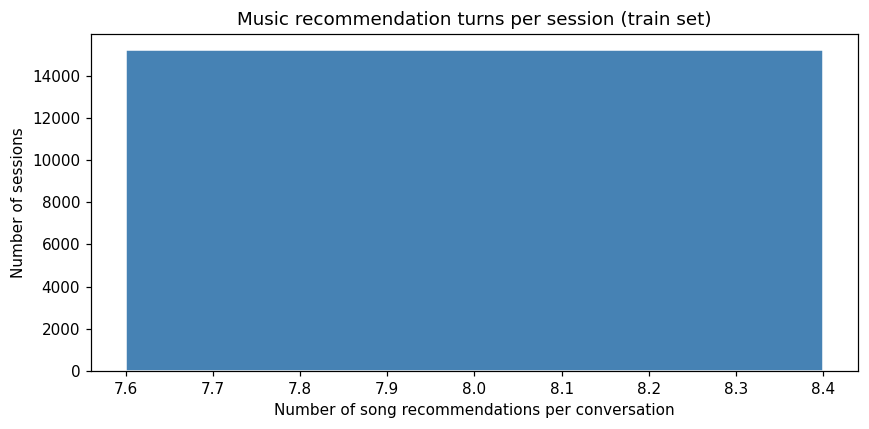

 # Music Turns  # Sessions
             8       15199


In [4]:
# How many music recommendation turns per session?
music_turn_counts = [
    sum(1 for t in session["conversations"] if t["role"] == "music")
    for session in conv_train
]
counts = Counter(music_turn_counts)
df_counts = pd.DataFrame(sorted(counts.items()), columns=["# Music Turns", "# Sessions"])

plt.figure(figsize=(8, 4))
plt.bar(df_counts["# Music Turns"], df_counts["# Sessions"], color="steelblue", edgecolor="white")
plt.title("Music recommendation turns per session (train set)")
plt.xlabel("Number of song recommendations per conversation")
plt.ylabel("Number of sessions")
plt.tight_layout()
plt.show()
print(df_counts.to_string(index=False))

In [5]:
# Conversation goals
goals = [s["conversation_goal"]["category"] for s in conv_train]
print("Goal categories:", dict(Counter(goals)))
print("\nSample listener goals:")
seen = set()
for session in conv_train:
    cat = session["conversation_goal"]["category"]
    if cat not in seen:
        print(f"  [{cat}] {session['conversation_goal']['listener_goal'][:100]}")
        seen.add(cat)
    if len(seen) >= 5:
        break

Goal categories: {'H': 2195, 'K': 1960, 'D': 1204, 'C': 978, 'F': 1087, 'J': 1496, 'A': 1084, 'G': 1359, 'B': 2149, 'E': 1300, 'I': 387}

Sample listener goals:
  [H] The listener wants to explore different artists and discover new songs from a broad collection, focu
  [K] discover multiple punk and alternative rock songs from the 2000s, exploring the sound of that era.
  [D] find one specific Nine Inch Nails song that's perfect for a high-energy workout, but can't remember 
  [C] find one specific album remembered by its distinctive and provocative cover art featuring an androgy
  [F] find multiple Black Keys tracks with specific characteristics, such as gritty, lo-fi sound, prominen


---
## Dataset 2: Track Catalog — 47,071 songs

Every song the system can recommend. Each track has:

| Field | Description |
|-------|-------------|
| `track_name` | Song title |
| `artist_name` | Artist(s) |
| `album_name` | Album |
| `tag_list` | Genre and mood tags (e.g. "rock", "relaxing", "electronic") |
| `popularity` | Popularity score 0–100 |
| `release_date` | Date released |
| `duration` | Length in milliseconds |

> `track_name`, `artist_name`, `album_name`, and `tag_list` are lists — a track can have multiple values.

In [6]:
print("Loading track catalog...")
tracks_ds = load_dataset("talkpl-ai/TalkPlayData-Challenge-Track-Metadata", split="all_tracks")
df_tracks = tracks_ds.to_pandas()
print(f"Total tracks: {len(df_tracks):,}")

def _first(lst): return lst[0] if lst is not None and len(lst) > 0 else ""
def _join4(lst): return ", ".join(lst[:4]) if lst is not None and len(lst) > 0 else ""

df_tracks["Track Name"] = df_tracks["track_name"].apply(_first)
df_tracks["Artist"]     = df_tracks["artist_name"].apply(_first)
df_tracks["Album"]      = df_tracks["album_name"].apply(_first)
df_tracks["Top Tags"]   = df_tracks["tag_list"].apply(_join4)

df_tracks[["Track Name", "Artist", "Album", "Top Tags", "popularity", "release_date"]].head(8)

Loading track catalog...


Total tracks: 47,071


,Track Name,Artist,Album,Top Tags,popularity,release_date
0,With Rainy Eyes,Emancipator,Soon It Will Be Cold Enough,"relaxing, experimental, goeiepoep, Instrumental",39.0,2006-12-06
1,Time After Time,The Wind and The Wave,Covers One,Alternative,31.0,2015-02-17
2,(I Left My Heart) In San Francisco,Tony Bennett,I Left My Heart In San Francisco,"pop, jazzyscrooners, soundtrack, playable around robin",59.0,1962-06-18
3,Suck My Kiss,Red Hot Chili Peppers,Blood Sugar Sex Magik (Deluxe Version),"energetic, alternative rock, funk metal, music that makes me hott",66.0,1991-09-24
4,Scourge of Iron,Cannibal Corpse,Torture,"jeff young, royal ruckus, Metal, torture",56.0,2012-03-13
5,Cassidy,Brett Dennen,Cassidy,Singer/Songwriter,44.0,2016-05-20
6,Willie Burke Sherwood,Killer Mike,R.A.P. Music,"2012, southern rap, Hip-Hop/Rap, hip hop",27.0,2012-05-15
7,Time of Our Lives,Pitbull,Time of Our Lives,"2014 single, superpop, fallon, house",87.0,2014-11-24


In [7]:
# Build fast lookup from HF dataset directly (gives Python dicts, not pandas Series)
track_meta = {item["track_id"]: item for item in tracks_ds}
print(f"Track lookup ready: {len(track_meta):,} entries")

Track lookup ready: 47,071 entries


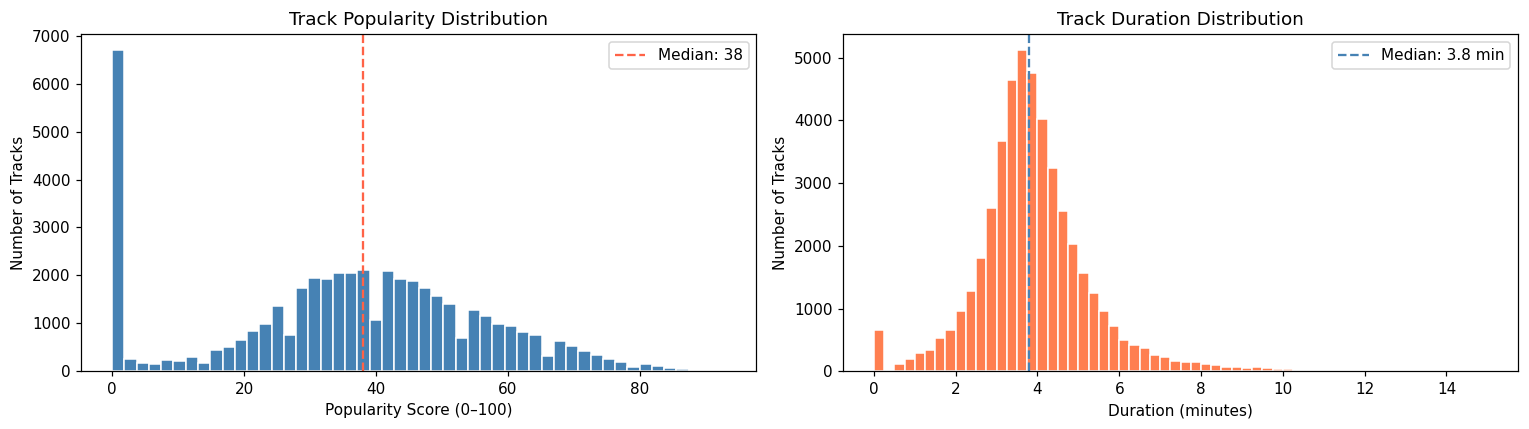

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

pop = df_tracks["popularity"].dropna()
axes[0].hist(pop, bins=50, color="steelblue", edgecolor="white")
axes[0].axvline(pop.median(), color="tomato", linestyle="--", label=f"Median: {pop.median():.0f}")
axes[0].set_title("Track Popularity Distribution")
axes[0].set_xlabel("Popularity Score (0–100)")
axes[0].set_ylabel("Number of Tracks")
axes[0].legend()

dur = df_tracks["duration"].dropna() / 60000
dur_clip = dur[dur < 15]
axes[1].hist(dur_clip, bins=60, color="coral", edgecolor="white")
axes[1].axvline(dur_clip.median(), color="steelblue", linestyle="--", label=f"Median: {dur_clip.median():.1f} min")
axes[1].set_title("Track Duration Distribution")
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("Number of Tracks")
axes[1].legend()

plt.tight_layout()
plt.show()

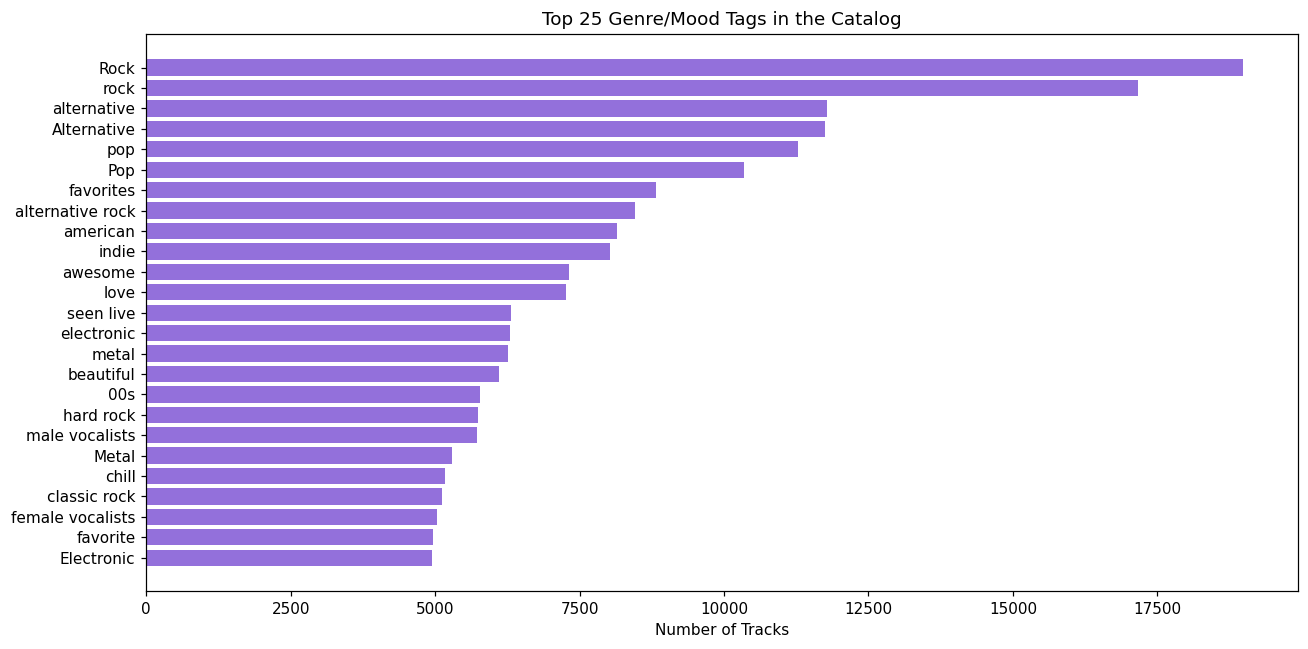

In [9]:
# Top 25 genre/mood tags
all_tags = [tag for tags in df_tracks["tag_list"] if tags is not None and len(tags) > 0 for tag in tags]
tag_counts = Counter(all_tags)
top_tags = pd.DataFrame(tag_counts.most_common(25), columns=["Tag", "Count"])

plt.figure(figsize=(12, 6))
plt.barh(top_tags["Tag"][::-1], top_tags["Count"][::-1], color="mediumpurple")
plt.title("Top 25 Genre/Mood Tags in the Catalog")
plt.xlabel("Number of Tracks")
plt.tight_layout()
plt.show()

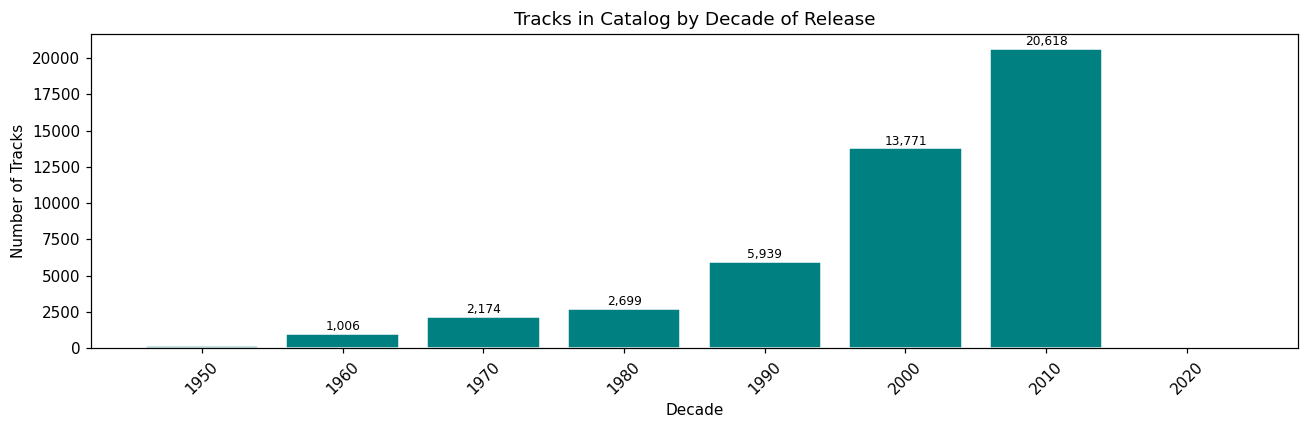

In [10]:
import pandas as pd
df_tracks["year"] = pd.to_datetime(df_tracks["release_date"], errors="coerce").dt.year
df_tracks["decade"] = (df_tracks["year"] // 10 * 10).astype("Int64")
decade_counts = df_tracks["decade"].value_counts().sort_index()
decade_counts = decade_counts[(decade_counts.index >= 1950) & (decade_counts.index <= 2030)]

plt.figure(figsize=(12, 4))
bars = plt.bar(decade_counts.index.astype(str), decade_counts.values, color="teal", edgecolor="white")
plt.title("Tracks in Catalog by Decade of Release")
plt.xlabel("Decade")
plt.ylabel("Number of Tracks")
plt.xticks(rotation=45)
for bar, val in zip(bars, decade_counts.values):
    if val > 500:
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f"{val:,}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.show()

---
## Dataset 3: User Profiles — 8,772 users

Each conversation is linked to a user. The system can use this profile to personalize the LLM system prompt.

In [11]:
print("Loading user profiles...")
users_ds = load_dataset("talkpl-ai/TalkPlayData-Challenge-User-Metadata", split="all_users")
df_users = users_ds.to_pandas()
print(f"Total users: {len(df_users):,}")
df_users.head(5)

Loading user profiles...


Total users: 8,772


,user_id,age,age_group,country_code,country_name,gender
0,5e51258a-27e3-4b49-aed9-10c9d05f139c,19,10s,BG,Bulgaria,female
1,0c7e49b3-c87b-4759-8da2-cfd400af29bf,31,30s,US,United States,male
2,913ac17d-a698-4da0-96cf-097b6909443e,17,10s,RU,Russia,female
3,b246106b-d26a-47f0-a70f-b17674dd608a,20,20s,FR,France,male
4,68aa6a54-2856-448c-ae2e-785bef3cc7b7,20,20s,BR,Brazil,male


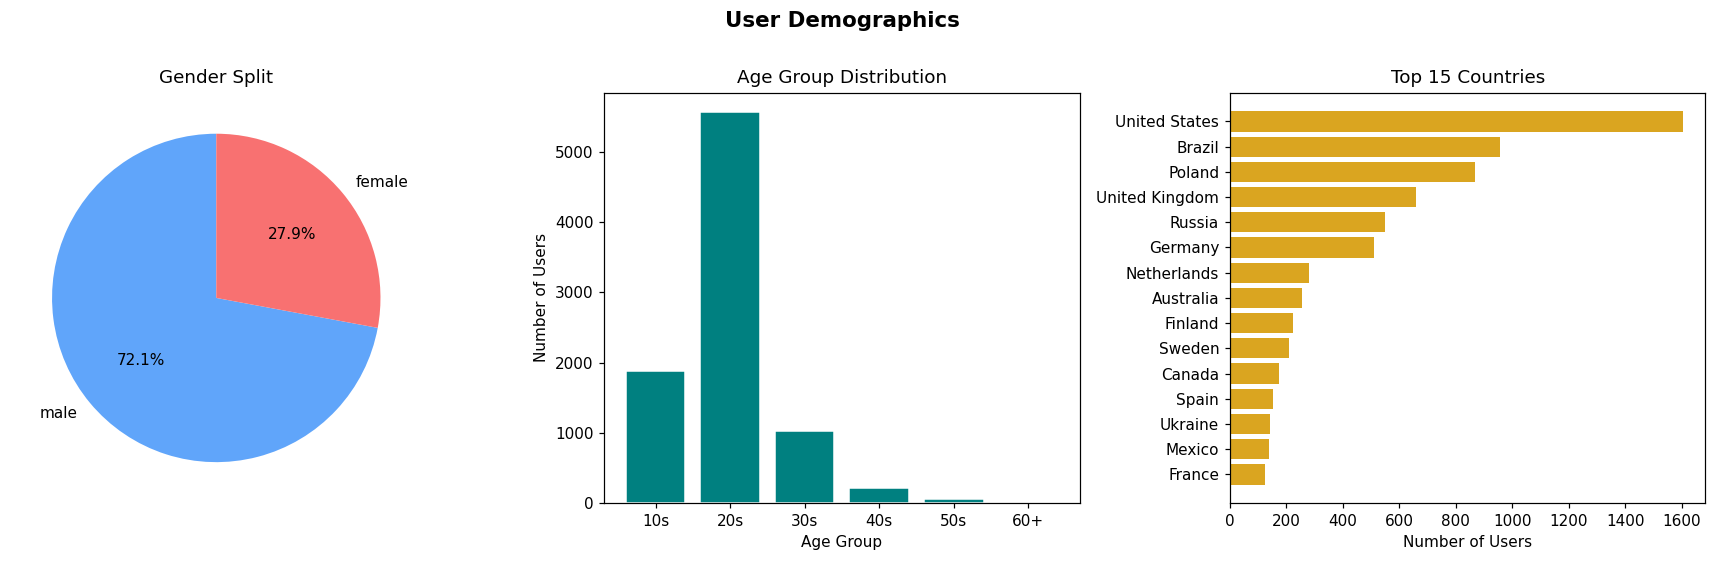

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

gender = df_users["gender"].value_counts()
axes[0].pie(gender, labels=gender.index, autopct="%1.1f%%", colors=["#60a5fa", "#f87171"], startangle=90)
axes[0].set_title("Gender Split")

age = df_users["age_group"].value_counts().sort_index()
axes[1].bar(age.index, age.values, color="teal", edgecolor="white")
axes[1].set_title("Age Group Distribution")
axes[1].set_xlabel("Age Group")
axes[1].set_ylabel("Number of Users")

countries = df_users["country_name"].value_counts().head(15)
axes[2].barh(countries.index[::-1], countries.values[::-1], color="goldenrod")
axes[2].set_title("Top 15 Countries")
axes[2].set_xlabel("Number of Users")

plt.suptitle("User Demographics", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## What We're Predicting

For every turn, the system must pick 20 tracks from 47,071. The single correct answer is the track ID in `role=="music"` turns.

Let's revisit the same session — now with real song names from the catalog!

In [13]:
display_conversation(conv_train[0], track_meta=track_meta)

Turn 1 · UserI want to discover some new artists. Do you have anything that's a bit intense or dramatic?
"🎵 Ground Truth Song (Turn 1)The Fiend — AlesanaA Place Where The Sun Is Silent · emocore, screamo, alesana, Alternative"
"Turn 1 · AssistantAwesome! Glad you liked that one. Sticking with the Alesana vibe for you, how about ""The Fiend""? It's got that classic intensity and screamo you love from them."
"Turn 2 · UserOh, Alesana is amazing, I love them! ""The Fiend"" is definitely intense. But I'm actually looking for new artists to discover, so could you recommend something intense or dramatic, but by someone I haven't heard before?"
"🎵 Ground Truth Song (Turn 2)A Forbidden Dance — AlesanaA Place Where The Sun Is Silent · emocore, screamo, american, hardcore"
"Turn 2 · AssistantAwesome, another hit! Let's keep the Alesana train rolling with ""A Forbidden Dance."" It's got that same intense energy and post-hardcore vibe you're loving!"
"Turn 3 · UserOkay, I really appreciate the Alesana tracks, they're fantastic! But I *really* want to discover new artists. Can you please play me something by an artist I haven't heard before, something with that intense post-hardcore energy?"
"🎵 Ground Truth Song (Turn 3)The Temptress — AlesanaA Place Where The Sun Is Silent · emocore, screamo, american, hardcore"
"Turn 3 · AssistantYou got it! Since you're still on an Alesana kick, let's try ""The Temptress."" It's got that powerful, emotional drive and screamo you love!"
"Turn 4 · UserI *really* need to hear something by a *completely different artist*. I love Alesana, but I already know all their music. Please, can you recommend an intense or dramatic post-hardcore track by an artist I haven't mentioned or heard before? I want to discover something new!"
"🎵 Ground Truth Song (Turn 4)Circle VII: Sins Of The Lion — AlesanaA Place Where The Sun Is Silent · emocore, screamo, alesana, donnie murry"


In [14]:
gt_track_ids = [
    t["content"]
    for session in conv_train
    for t in session["conversations"]
    if t["role"] == "music"
]
gt_unique = set(gt_track_ids)

print(f"Total music turns in train set:      {len(gt_track_ids):,}")
print(f"Unique ground truth tracks:           {len(gt_unique):,}")
print(f"Catalog size:                         {len(track_meta):,}")
print(f"GT tracks as % of catalog:            {len(gt_unique)/len(track_meta):.1%}")

top20_pop = df_tracks.nlargest(20, "popularity")["track_id"].tolist()
overlap = len(gt_unique.intersection(top20_pop))
print(f"\nOverlap between GT and top-20 most popular: {overlap}")
print("→ Can't cheat with popularity. The system must understand the conversation!")

Total music turns in train set:      121,592
Unique ground truth tracks:           43,597
Catalog size:                         47,071
GT tracks as % of catalog:            92.6%

Overlap between GT and top-20 most popular: 20
→ Can't cheat with popularity. The system must understand the conversation!


In [15]:
# Most frequently recommended tracks in training data
gt_freq = Counter(gt_track_ids)
top_gt = pd.DataFrame(gt_freq.most_common(15), columns=["track_id", "times_recommended"])

def _first(lst): return lst[0] if lst is not None and len(lst) > 0 else "?"

top_gt["Track Name"] = top_gt["track_id"].map(
    lambda tid: _first(track_meta[tid]["track_name"]) if tid in track_meta else "?"
)
top_gt["Artist"] = top_gt["track_id"].map(
    lambda tid: _first(track_meta[tid]["artist_name"]) if tid in track_meta else "?"
)
top_gt[["Track Name", "Artist", "times_recommended"]]

,Track Name,Artist,times_recommended
0,In the End,Linkin Park,128
1,Numb,Linkin Park,103
2,Everlong,Foo Fighters,83
3,Supermassive Black Hole,Muse,82
4,Crawling,Linkin Park,81
5,Pumped Up Kicks,Foster The People,81
6,Papercut,Linkin Park,81
7,Scar Tissue,Red Hot Chili Peppers,80
8,Fix You,Coldplay,74
9,Otherside,Red Hot Chili Peppers,74


---
## How is Performance Measured?

### NDCG@K

We return a ranked list of 20 tracks. The ground truth is **one** correct track.

- Correct track at **rank 1** → full score (1.0)
- Correct track at **rank 5** → partial (1 / log₂(6) ≈ 0.39)
- Correct track at **rank 20** → small (1 / log₂(21) ≈ 0.23)
- **Not in the list** → score = 0

**NDCG@10** is the primary metric — only the top 10 predictions count.

In [16]:
leaderboard = pd.DataFrame([
    {"Model": "BM25 + Llama-1B",       "NDCG@1": 0.0098, "NDCG@10": 0.0627, "NDCG@20": 0.0815, "Catalog Diversity": 0.3795},
    {"Model": "BERT + Llama-1B",       "NDCG@1": 0.0018, "NDCG@10": 0.0048, "NDCG@20": 0.0063, "Catalog Diversity": 0.0607},
    {"Model": "Always top-20 popular", "NDCG@1": 0.0005, "NDCG@10": 0.0018, "NDCG@20": 0.0024, "Catalog Diversity": 0.0004},
    {"Model": "Random 20 tracks",      "NDCG@1": 0.0000, "NDCG@10": 0.0001, "NDCG@20": 0.0001, "Catalog Diversity": 0.9652},
])
display(leaderboard)
print("\nBM25+Llama is 13× better than BERT — keyword search is surprisingly effective!")
print("All scores are low — this is genuinely hard. Plenty of room for improvement!")

,Model,NDCG@1,NDCG@10,NDCG@20,Catalog Diversity
0,BM25 + Llama-1B,0.0098,0.0627,0.0815,0.3795
1,BERT + Llama-1B,0.0018,0.0048,0.0063,0.0607
2,Always top-20 popular,0.0005,0.0018,0.0024,0.0004
3,Random 20 tracks,0.0000,0.0001,0.0001,0.9652



BM25+Llama is 13× better than BERT — keyword search is surprisingly effective!
All scores are low — this is genuinely hard. Plenty of room for improvement!


---
## Summary

| Dataset | Size | Key takeaway |
|---------|------|--------------|
| Conversations | 15,199 train sessions, 8 turns each | Each `music` turn is a ground-truth track to predict |
| Track Catalog | 47,071 songs | Diverse genres; most tracks are low-popularity |
| User Profiles | 8,772 users | Global, young skew, balanced gender |

**Next:** Open `02_make_a_prediction.ipynb` to see the prediction pipeline in action.